# GraphEstimator on PubChem: supervised and unsupervised modes

This notebook shows how to use `GraphEstimator` in both:

- supervised mode with activity labels
- unsupervised mode with the built-in `IsolationForestProba` fallback

The molecular graphs are loaded with the chemistry loader from
`abstractgraph-graphicalizer`, using local PubChem SDF exports.

In [1]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split

from abstractgraph.operators import neighborhood
from abstractgraph.vectorize import AbstractGraphTransformer
from abstractgraph_ml.estimators import GraphEstimator
from abstractgraph_graphicalizer.chem import PubChemAssayLoader

## Dataset loader

This example uses `PubChemAssayLoader` from `abstractgraph_graphicalizer.chem`.
The first cell below lists the assays available from the currently resolved
PubChem root so you can choose a dataset interactively before loading it.


In [3]:
loader = PubChemAssayLoader(on_error="skip")

print("root:", loader.root)
print()
print(loader.format_assay_table())

assay_id = "651741"
paths = loader.resolve_paths(assay_id)
print()
print("selected:", paths)

active_graphs, inactive_graphs = loader.load_split(assay_id,limit=1000)

print("active graphs  ", len(active_graphs))
print("inactive graphs", len(inactive_graphs))

root: /home/fabrizio/code/abstractgraph-graphicalizer/data/PUBCHEM

assay_id    active_mols  inactive_mols  total_mols   total_mb
----------------------------------------------------------------
463230             1675            666        2341      14.57
492952             1453            841        2294      12.35
588350             1232            634        1866      11.17
651741              498            965        1463       6.18
624249              355            173         528       3.76
2631                273             97         370       2.22

selected: PubChemAssayPaths(assay_id='651741', active_path=PosixPath('/home/fabrizio/code/abstractgraph-graphicalizer/data/PUBCHEM/AID651741_active.sdf'), inactive_path=PosixPath('/home/fabrizio/code/abstractgraph-graphicalizer/data/PUBCHEM/AID651741_inactive.sdf'))
active graphs   498
inactive graphs 965


In [4]:
graphs = inactive_graphs + active_graphs
targets = np.array([0] * len(inactive_graphs) + [1] * len(active_graphs))
target_names = {0: "inactive", 1: "active"}

pd.Series(targets).map(target_names).value_counts().rename_axis("label").to_frame("count")


,count
label,
inactive,965
active,498


## Shared structural feature pipeline

Both modes below use the same decomposition and vectorization setup.
Here we use a compact local-structure decomposition based on
`neighborhood(radius=(0, 1))`.

In [5]:
def make_transformer():
    return AbstractGraphTransformer(
        nbits=14,
        decomposition_function=neighborhood(radius=(0, 1)),
        return_dense=True,
        n_jobs=-1,
    )

train_graphs, test_graphs, y_train, y_test = train_test_split(
    graphs,
    targets,
    test_size=0.30,
    random_state=0,
    stratify=targets,
)

len(train_graphs), len(test_graphs)


(1024, 439)

## Supervised mode

In supervised mode, `GraphEstimator` wraps a standard downstream model.
Here we use a random forest and a 2D PCA manifold for visualization.

In [6]:
supervised_estimator = GraphEstimator(
    transformer=make_transformer(),
    estimator=RandomForestClassifier(n_estimators=200, random_state=0),
    manifold=PCA(n_components=2),
    n_selected_features=0.2,
)

supervised_estimator.fit(train_graphs, y_train)

supervised_proba = supervised_estimator.predict_proba(test_graphs)[:, 1]
supervised_pred = supervised_estimator.predict(test_graphs)
supervised_auc = roc_auc_score(y_test, supervised_proba)
supervised_acc = accuracy_score(y_test, supervised_pred)

pd.DataFrame([
    {
        "metric": "roc_auc",
        "value": supervised_auc,
    },
    {
        "metric": "accuracy",
        "value": supervised_acc,
    },
])


,metric,value
0,roc_auc,0.873895
1,accuracy,0.833713


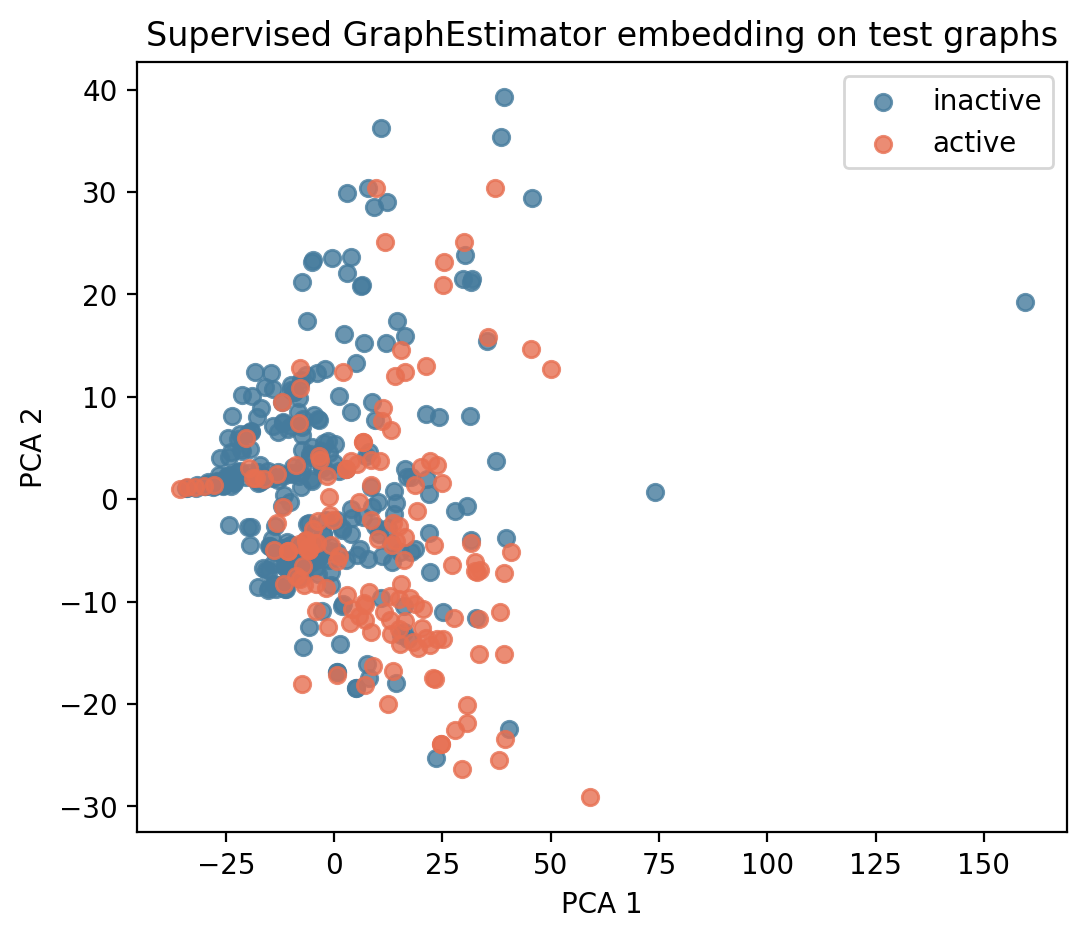

In [7]:
embedding = supervised_estimator.transform(test_graphs)

fig, ax = plt.subplots(figsize=(6, 5))
for cls, color in [(0, "#457b9d"), (1, "#e76f51")]:
    mask = y_test == cls
    ax.scatter(
        embedding[mask, 0],
        embedding[mask, 1],
        s=35,
        alpha=0.8,
        label=target_names[cls],
        color=color,
    )
ax.set_title("Supervised GraphEstimator embedding on test graphs")
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.legend()
plt.show()


## Unsupervised mode

If `estimator=None` and `targets=None`, `GraphEstimator` falls back to
`IsolationForestProba`.

Here we fit only on inactive molecules and use the resulting model as a
novelty detector over a mixed evaluation set.

Important: this is not a supervised activity model. The outlier score is a
novelty score relative to the inactive training distribution.

In [8]:
inactive_train = [graph for graph, target in zip(train_graphs, y_train) if target == 0]
inactive_test = [graph for graph, target in zip(test_graphs, y_test) if target == 0]
active_test = [graph for graph, target in zip(test_graphs, y_test) if target == 1]

novelty_graphs = inactive_test + active_test
novelty_targets = np.array([0] * len(inactive_test) + [1] * len(active_test))

unsupervised_estimator = GraphEstimator(
    transformer=make_transformer(),
    estimator=None,
    manifold=None,
    n_selected_features=None,
)

unsupervised_estimator.fit(inactive_train, targets=None)
inlier_proba = unsupervised_estimator.predict_proba(novelty_graphs)[:, 1]
novelty_score = 1.0 - inlier_proba

summary = pd.DataFrame(
    {
        "label": [target_names[t] for t in novelty_targets],
        "inlier_proba": inlier_proba,
        "novelty_score": novelty_score,
    }
)
summary.groupby("label").agg(["mean", "median", "std"])


inlier_proba                     novelty_score                    
                 mean    median       std          mean    median       std
label                                                                      
active       0.339915  0.282963  0.250799      0.660085  0.717037  0.250799
inactive     0.521456  0.528889  0.271680      0.478544  0.471111  0.271680

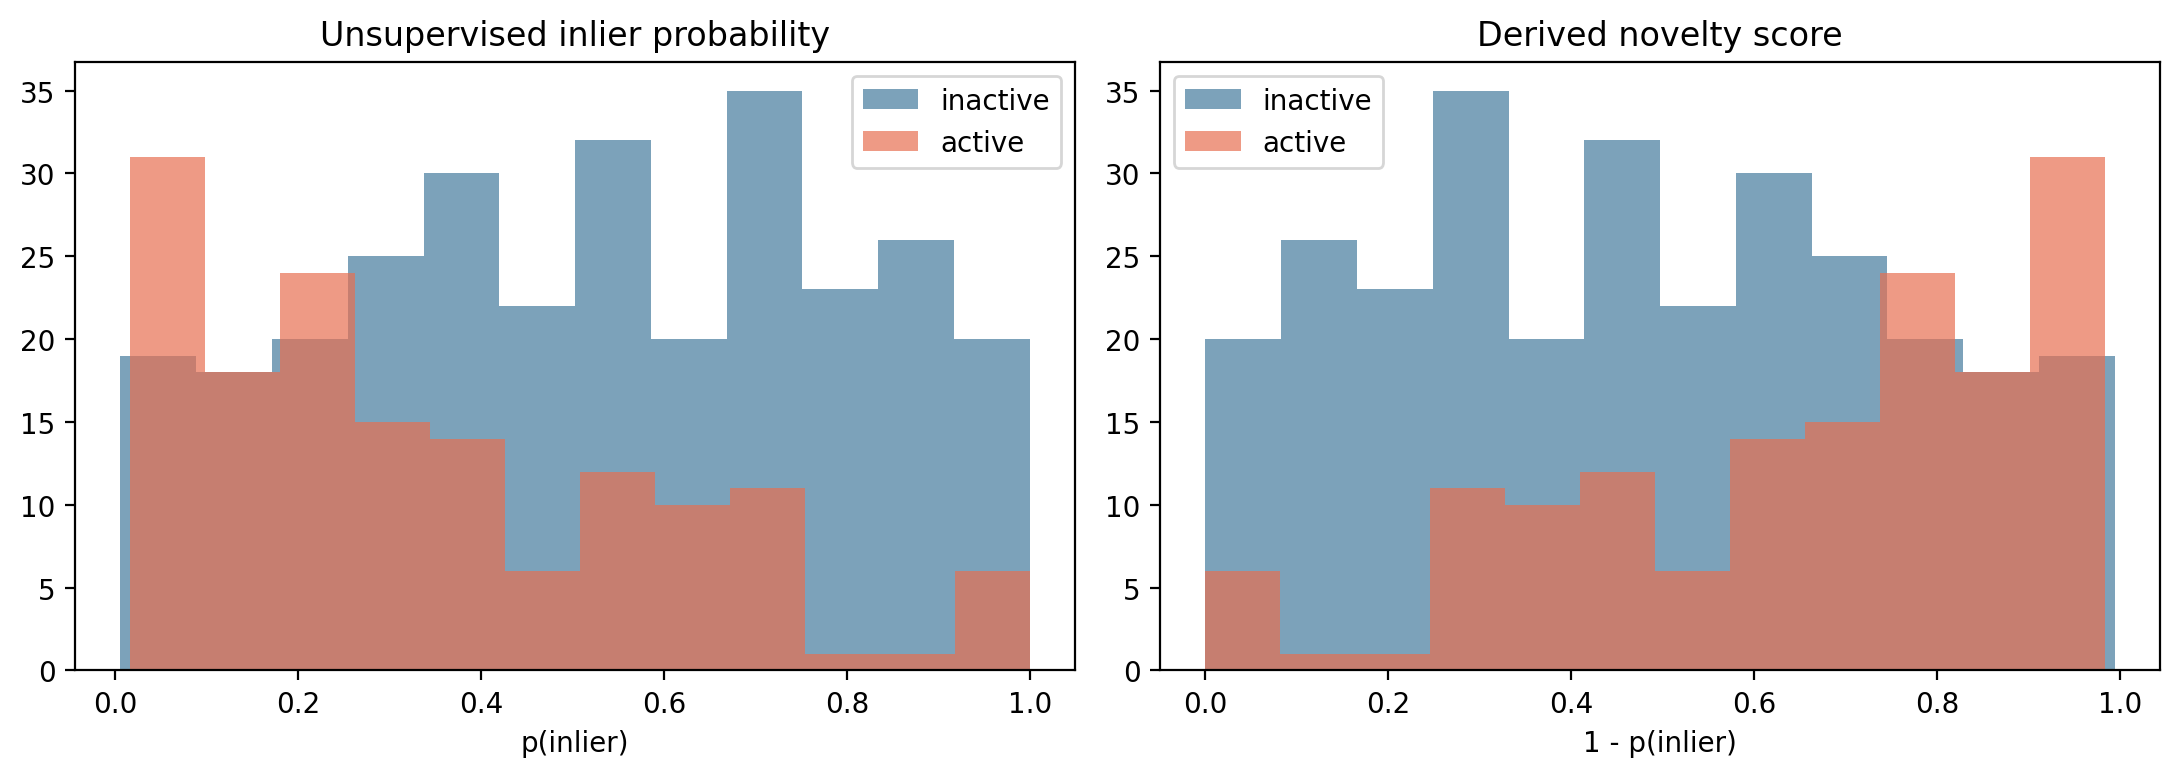

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for cls, color in [(0, "#457b9d"), (1, "#e76f51")]:
    mask = novelty_targets == cls
    axes[0].hist(inlier_proba[mask], bins=12, alpha=0.7, color=color, label=target_names[cls])
    axes[1].hist(novelty_score[mask], bins=12, alpha=0.7, color=color, label=target_names[cls])

axes[0].set_title("Unsupervised inlier probability")
axes[0].set_xlabel("p(inlier)")
axes[1].set_title("Derived novelty score")
axes[1].set_xlabel("1 - p(inlier)")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()


In [10]:
pd.DataFrame([
    {
        "note": "Optional diagnostic only",
        "roc_auc_against_activity_label": roc_auc_score(novelty_targets, novelty_score),
    }
])


,note,roc_auc_against_activity_label
0,Optional diagnostic only,0.690454


## Takeaways

- supervised `GraphEstimator` is the right mode when you have labels and
  want predictive performance
- unsupervised `GraphEstimator` is the right mode when you want a novelty or
  admissibility score relative to a reference graph distribution
- both modes share the same structural decomposition and vectorization layer,
  which is the main design advantage of the estimator API